# Análisis del Péndulo Simple — Estimación del Periodo de Oscilación
Este notebook procesa un video de un péndulo simple para:
1. **Detectar** la posición de la masa en cada frame (visión por computadora).
2. **Reconstruir** la trayectoria angular $\theta(t)$.
3. **Estimar** el periodo de oscilación usando:
   - Cruces por cero (*zero-crossing method*).
   - Detección de picos (*peak detection*).
   - **Transformada de Fourier (FFT)** y análisis espectral.
4. **Comparar** con el valor teórico $T = 2\pi\sqrt{L/g}$.
5. **Analizar** fuentes de error y limitaciones.

---
### Parámetros conocidos de la simulación
| Parámetro | Valor |
|---|---|
| $g$ | 9.81 m/s² |
| $L$ | 1.0 m |
| $\theta_0$ | 45° |
| $\mu$ (fricción) | 0.05 |
| FPS | 30 |
| Escala | 400 px/m |

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
import os

# Matplotlib estilo global
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
%matplotlib inline

---
## 1. Carga del video y extracción de metadatos

In [2]:
# --- Ruta al video ---
BASE_DIR = os.getcwd()
VIDEO_PATH = os.path.join(BASE_DIR, "pendulo_simulado.mp4")

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"No se pudo abrir el video: {VIDEO_PATH}")

FPS = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION = TOTAL_FRAMES / FPS

print("=" * 50)
print("  METADATOS DEL VIDEO")
print("=" * 50)
print(f"  Resolución : {WIDTH} x {HEIGHT} px")
print(f"  FPS        : {FPS}")
print(f"  Frames     : {TOTAL_FRAMES}")
print(f"  Duración   : {DURATION:.2f} s")
print("=" * 50)

  METADATOS DEL VIDEO
  Resolución : 800 x 600 px
  FPS        : 30.0
  Frames     : 450
  Duración   : 15.00 s


---
## 2. Detección de la masa del péndulo (frame a frame)
La masa se dibujó como un **círculo rojo** (`BGR = (0, 0, 200)`) sobre fondo blanco.
Usamos un filtrado en el espacio de color **HSV** para aislar la masa y encontrar
 su centroide mediante momentos de imagen.

In [3]:
def detect_pendulum_mass(frame, lower_hsv, upper_hsv, min_area=100):
    """
    Detecta la masa del péndulo en un frame dado un rango HSV.
    Retorna el centroide (cx, cy) o None si no se detecta.
    """
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

    # Operaciones morfológicas para limpiar ruido
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < min_area:
        return None

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return (cx, cy)

### 2.1 Rango HSV para la masa roja
El color en BGR es `(0, 0, 200)`. En HSV de OpenCV (H: 0–180), esto corresponde
aproximadamente a un rojo puro con H ≈ 0 (o ≈ 180), alta saturación y valor medio.

In [4]:
# Rango HSV amplio para capturar la esfera roja
LOWER_HSV = np.array([0, 80, 80])
UPPER_HSV = np.array([15, 255, 255])

### 2.2 Procesamiento del video completo

In [5]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Rebobinar al inicio

times = []
x_positions = []
y_positions = []

frame_idx = 0
detections = 0

print("Procesando video frame a frame...")
while True:
    ret, frame = cap.read()
    if not ret:
        break

    center = detect_pendulum_mass(frame, LOWER_HSV, UPPER_HSV)
    if center is not None:
        t = frame_idx / FPS
        times.append(t)
        x_positions.append(center[0])
        y_positions.append(center[1])
        detections += 1

    frame_idx += 1

cap.release()

times = np.array(times)
x_positions = np.array(x_positions, dtype=float)
y_positions = np.array(y_positions, dtype=float)

print(f"✅ Detecciones exitosas: {detections}/{frame_idx} frames ({100*detections/frame_idx:.1f}%)")

Procesando video frame a frame...
✅ Detecciones exitosas: 450/450 frames (100.0%)


---
## 3. Reconstrucción de la trayectoria
Conocemos el **pivote** del péndulo (centro superior del lienzo) y podemos
reconstruir el ángulo $\theta$ a partir de las coordenadas $(x, y)$ detectadas:
$$\theta = \arctan\!\left(\frac{x - x_{\text{pivote}}}{y - y_{\text{pivote}}}\right)$$

In [6]:
# Coordenadas del pivote (del script de simulación: origin = (400, 100))
PIVOT_X = WIDTH // 2   # 400
PIVOT_Y = 100

# Calcular el ángulo theta respecto al pivote
dx = x_positions - PIVOT_X
dy = y_positions - PIVOT_Y
theta_measured = np.arctan2(dx, dy)  # radianes

### 3.1 Gráfica de la posición $(x, y)$ en función del tiempo

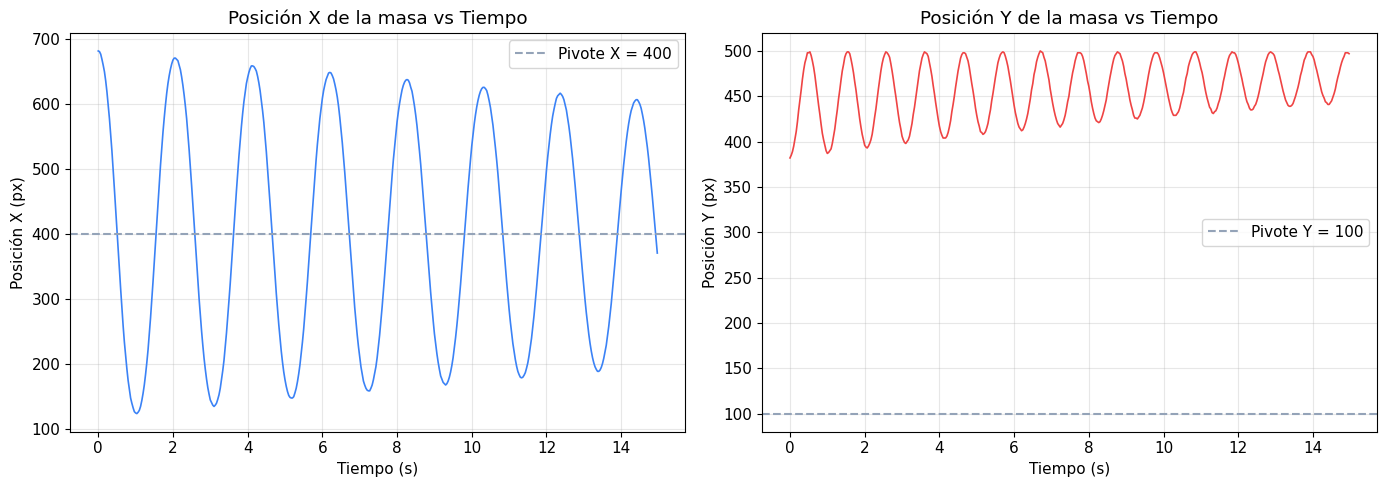

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Posición X ---
axes[0].plot(times, x_positions, color="#3b82f6", linewidth=1.2)
axes[0].axhline(y=PIVOT_X, color="#94a3b8", linestyle="--", label=f"Pivote X = {PIVOT_X}")
axes[0].set_title("Posición X de la masa vs Tiempo")
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Posición X (px)")
axes[0].legend()

# --- Posición Y ---
axes[1].plot(times, y_positions, color="#ef4444", linewidth=1.2)
axes[1].axhline(y=PIVOT_Y, color="#94a3b8", linestyle="--", label=f"Pivote Y = {PIVOT_Y}")
axes[1].set_title("Posición Y de la masa vs Tiempo")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Posición Y (px)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Gráfica del ángulo $\theta(t)$

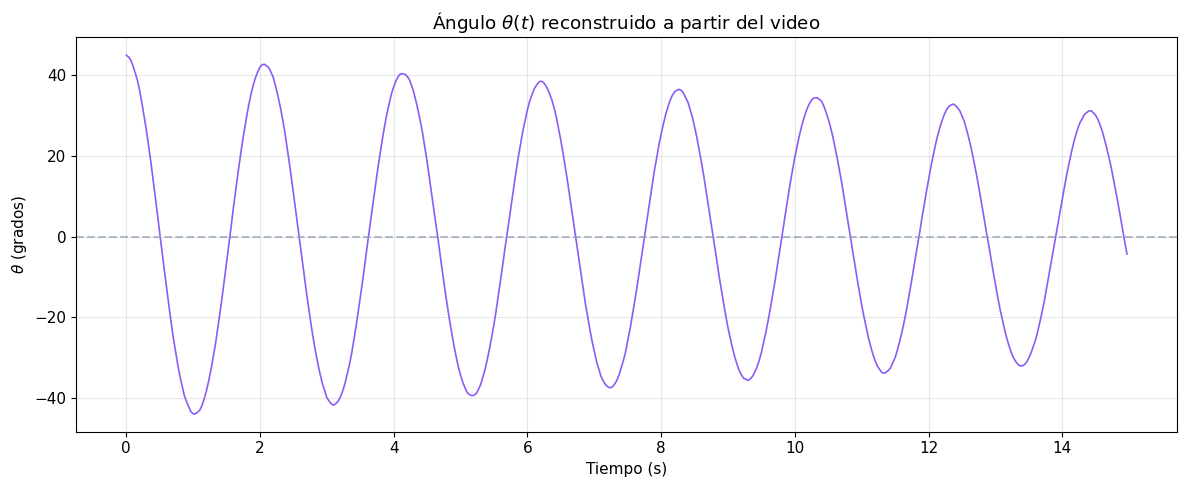

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, np.degrees(theta_measured), color="#8b5cf6", linewidth=1.2)
ax.set_title(r"Ángulo $\theta(t)$ reconstruido a partir del video")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel(r"$\theta$ (grados)")
ax.axhline(y=0, color="#94a3b8", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

---
## 4. Estimación del periodo de oscilación
Utilizamos tres métodos independientes para estimar $T$:

| Método | Descripción |
|---|---|
| **Cruces por cero** | Detecta cada vez que $\theta$ cruza $0°$ y promedia el semi-periodo. |
| **Detección de picos** | Encuentra máximos locales sucesivos y promedia las distancias temporales. |
| **Transformada de Fourier (FFT)** | Identifica la frecuencia fundamental en el espectro de potencia. |

### 4.1 Método 1 — Cruces por cero (*Zero-Crossing*)

In [9]:
# Detectar cruces por cero: cuando el signo de theta cambia entre frames consecutivos
sign_changes = np.where(np.diff(np.sign(theta_measured)))[0]
zero_crossing_times = times[sign_changes]

# El periodo es el doble del intervalo medio entre cruces consecutivos (cada cruce = medio periodo)
if len(zero_crossing_times) >= 2:
    half_periods = np.diff(zero_crossing_times)
    T_zero_crossing = 2.0 * np.mean(half_periods)
    T_zc_std = 2.0 * np.std(half_periods)
    print(f"📐 Método Cruces por Cero:")
    print(f"   T = {T_zero_crossing:.4f} ± {T_zc_std:.4f} s")
    print(f"   Cruces detectados: {len(zero_crossing_times)}")
else:
    T_zero_crossing = None
    print("⚠️  No se detectaron suficientes cruces por cero.")

📐 Método Cruces por Cero:
   T = 1.9200 ± 0.4960 s
   Cruces detectados: 16


### 4.2 Método 2 — Detección de picos (*Peak Detection*)


📐 Método Detección de Picos:
   T = 2.0556 ± 0.0248 s
   Picos detectados: 7


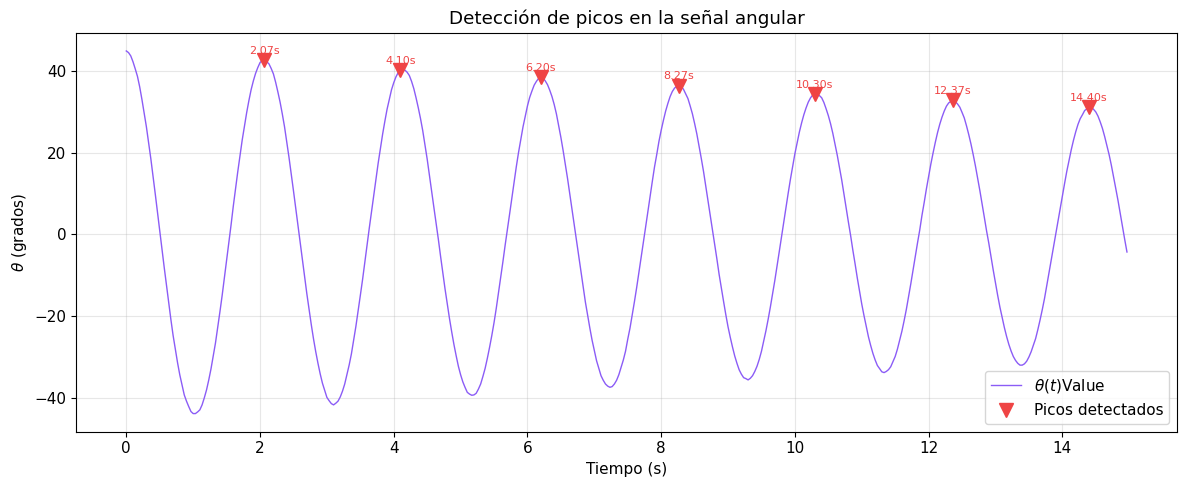

In [10]:
# Detectar máximos locales (picos positivos) en la señal de theta
peak_indices, _ = find_peaks(theta_measured, prominence=0.05, distance=int(FPS * 0.5))
peak_times = times[peak_indices]
peak_values = np.degrees(theta_measured[peak_indices])

if len(peak_times) >= 2:
    periods_peaks = np.diff(peak_times)
    T_peaks = np.mean(periods_peaks)
    T_peaks_std = np.std(periods_peaks)
    print(f"\n📐 Método Detección de Picos:")
    print(f"   T = {T_peaks:.4f} ± {T_peaks_std:.4f} s")
    print(f"   Picos detectados: {len(peak_times)}")
else:
    T_peaks = None
    print("⚠️  No se detectaron suficientes picos.")

# --- Gráfica de picos detectados ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, np.degrees(theta_measured), color="#8b5cf6", linewidth=1.0, label=r"$\theta(t)$Value")
ax.plot(peak_times, peak_values, "v", color="#ef4444", markersize=10, label="Picos detectados")

# Anotar los picos
for i in range(len(peak_times)):
    ax.annotate(f"{peak_times[i]:.2f}s", (peak_times[i], peak_values[i] + 1.5),
                fontsize=8, ha='center', color="#ef4444")

ax.set_title("Detección de picos en la señal angular")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel(r"$\theta$ (grados)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Método 3 — Transformada de Fourier (FFT)
La FFT permite descomponer la señal $\theta(t)$ en sus componentes de frecuencia.
La **frecuencia fundamental** $f_0$ corresponde al pico más prominente del espectro,
y el periodo se obtiene como $T = 1/f_0$.


📐 Método FFT (Transformada de Fourier):
   Frecuencia fundamental f₀ = 0.4667 Hz
   T = 1/f₀ = 2.1429 s


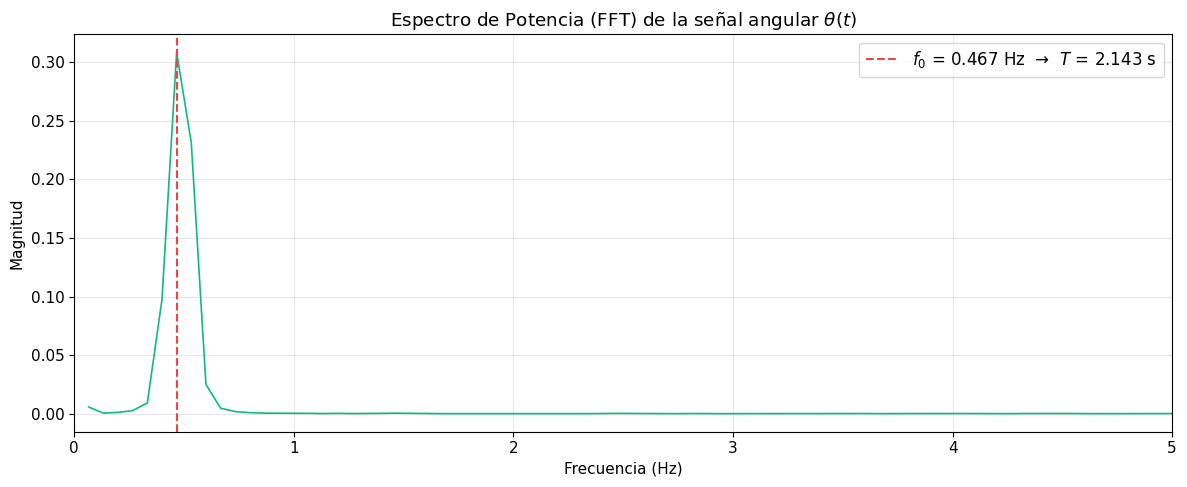

In [11]:
N = len(theta_measured)
dt = 1.0 / FPS

# Remover la media (componente DC) para un mejor análisis espectral
theta_centered = theta_measured - np.mean(theta_measured)

# Aplicar ventana de Hanning para reducir el leakage espectral
window = np.hanning(N)
theta_windowed = theta_centered * window

# Calcular la FFT
yf = fft(theta_windowed)
xf = fftfreq(N, dt)

# Tomar solo la mitad positiva del espectro
positive_mask = xf > 0
freqs = xf[positive_mask]
power_spectrum = 2.0 / N * np.abs(yf[positive_mask])

# Encontrar la frecuencia fundamental (pico dominante)
dominant_idx = np.argmax(power_spectrum)
f0 = freqs[dominant_idx]
T_fft = 1.0 / f0

print(f"\n📐 Método FFT (Transformada de Fourier):")
print(f"   Frecuencia fundamental f₀ = {f0:.4f} Hz")
print(f"   T = 1/f₀ = {T_fft:.4f} s")

# --- Gráfica del espectro de potencia ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(freqs, power_spectrum, color="#10b981", linewidth=1.2)
ax.axvline(x=f0, color="#ef4444", linestyle="--", linewidth=1.5,
           label=f"$f_0$ = {f0:.3f} Hz  →  $T$ = {T_fft:.3f} s")
ax.set_title("Espectro de Potencia (FFT) de la señal angular $\\theta(t)$")
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Magnitud")
ax.set_xlim(0, 5)  # Limitar a frecuencias razonables
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 4.4 Reconstrucción por Series de Fourier
Reconstruimos la señal $\theta(t)$ utilizando los **primeros $K$ armónicos**
de la Transformada de Fourier.

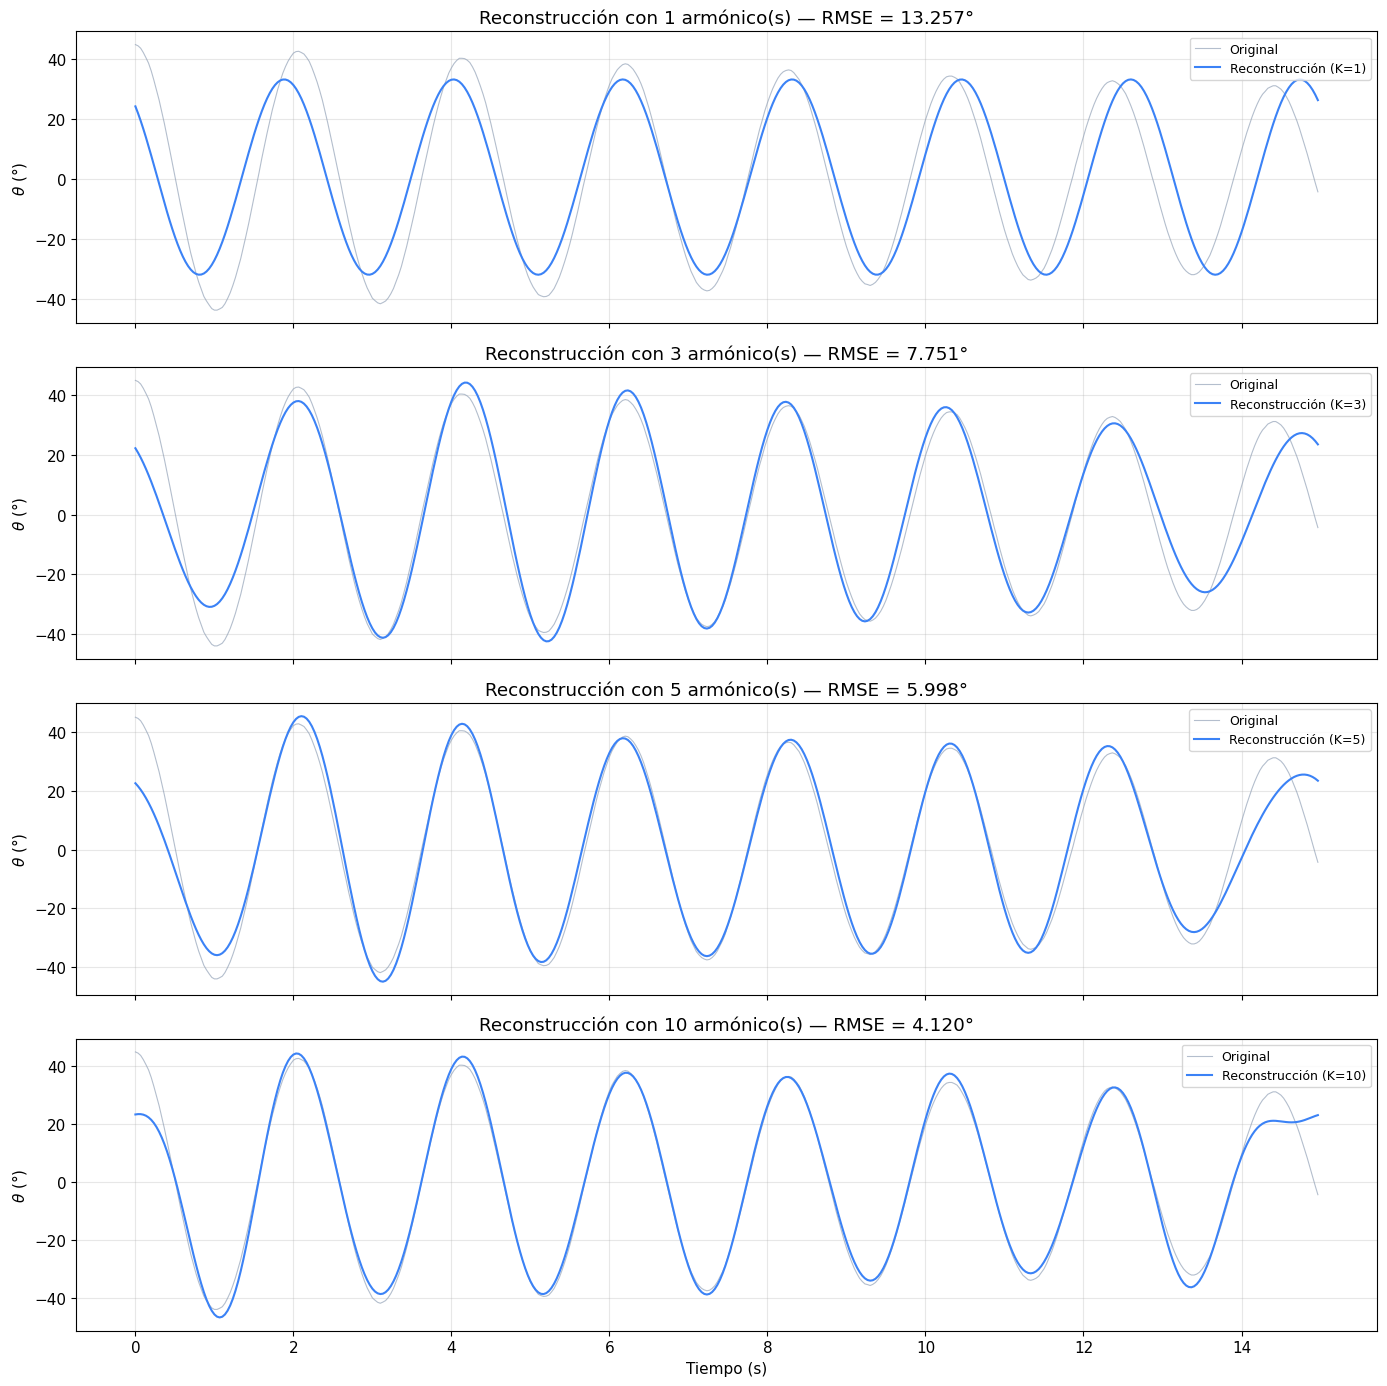

In [12]:
# Número de armónicos a utilizar en la reconstrucción
K_harmonics_list = [1, 3, 5, 10]

fig, axes = plt.subplots(len(K_harmonics_list), 1, figsize=(14, 3.5 * len(K_harmonics_list)), sharex=True)

from scipy.fft import ifft

for idx, K in enumerate(K_harmonics_list):
    yf_full = fft(theta_centered)
    magnitudes = np.abs(yf_full[:N // 2])
    top_k_indices = np.argsort(magnitudes)[-K:]

    yf_filtered = np.zeros_like(yf_full)
    for ki in top_k_indices:
        yf_filtered[ki] = yf_full[ki]
        yf_filtered[N - ki] = yf_full[N - ki]

    theta_reconstructed = np.real(ifft(yf_filtered)) + np.mean(theta_measured)
    rms_error = np.sqrt(np.mean((theta_measured - theta_reconstructed) ** 2))

    axes[idx].plot(times, np.degrees(theta_measured), color="#94a3b8", linewidth=0.8, label="Original", alpha=0.7)
    axes[idx].plot(times, np.degrees(theta_reconstructed), color="#3b82f6", linewidth=1.5, label=f"Reconstrucción (K={K})")
    axes[idx].set_ylabel(r"$\theta$ (°)")
    axes[idx].set_title(f"Reconstrucción con {K} armónico(s) — RMSE = {np.degrees(rms_error):.3f}°")
    axes[idx].legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

---
## 5. Comparación con el valor teórico

  COMPARACIÓN DE PERIODOS
  T (lineal, ángulos pequeños) = 2.0061 s
  T (Borda, corrección θ₀=45°) = 2.0861 s
-------------------------------------------------------
  Cruces por Cero       : T = 1.9200 ± 0.4960 s
                          Error vs lineal: 4.29%
                          Error vs Borda:  7.96%

  Detección de Picos    : T = 2.0556 ± 0.0248 s
                          Error vs lineal: 2.47%
                          Error vs Borda:  1.47%

  FFT (Fourier)         : T = 2.1429 ± 0.0000 s
                          Error vs lineal: 6.82%
                          Error vs Borda:  2.72%



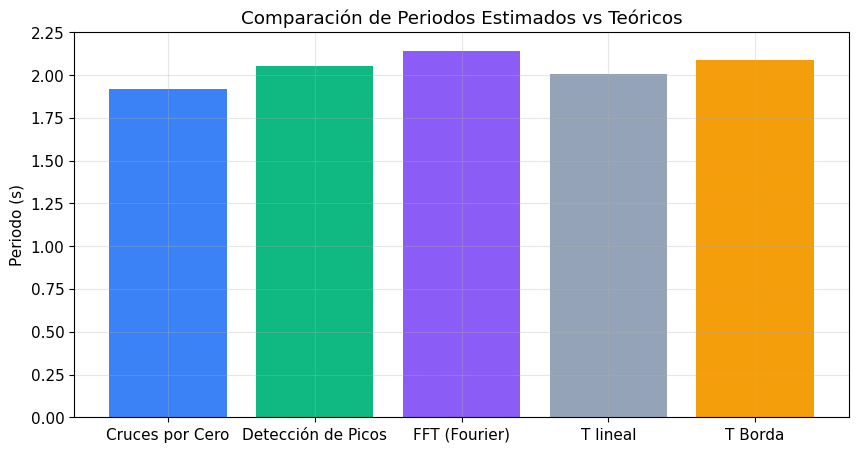

In [13]:
# Parámetros conocidos de la simulación
g = 9.81
L = 1.0
theta_0 = np.radians(45)

T_linear = 2 * np.pi * np.sqrt(L / g)
T_borda = T_linear * (1 + (1/16) * theta_0**2 + (11/3072) * theta_0**4)

print("=" * 55)
print("  COMPARACIÓN DE PERIODOS")
print("=" * 55)
print(f"  T (lineal, ángulos pequeños) = {T_linear:.4f} s")
print(f"  T (Borda, corrección θ₀=45°) = {T_borda:.4f} s")
print("-" * 55)

methods = {}
if T_zero_crossing is not None: methods["Cruces por Cero"] = (T_zero_crossing, T_zc_std)
if T_peaks is not None: methods["Detección de Picos"] = (T_peaks, T_peaks_std)
methods["FFT (Fourier)"] = (T_fft, 0.0)

for name, (T_est, T_std) in methods.items():
    error_lin = abs(T_est - T_linear) / T_linear * 100
    error_borda = abs(T_est - T_borda) / T_borda * 100
    print(f"  {name:22s}: T = {T_est:.4f} ± {T_std:.4f} s")
    print(f"  {'':22s}  Error vs lineal: {error_lin:.2f}%")
    print(f"  {'':22s}  Error vs Borda:  {error_borda:.2f}%")
    print()

fig, ax = plt.subplots(figsize=(10, 5))
labels = list(methods.keys()) + ["T lineal", "T Borda"]
values = [m[0] for m in methods.values()] + [T_linear, T_borda]
ax.bar(labels, values, color=["#3b82f6", "#10b981", "#8b5cf6", "#94a3b8", "#f59e0b"])
ax.set_ylabel("Periodo (s)")
ax.set_title("Comparación de Periodos Estimados vs Teóricos")
plt.show()

---
## 6. Decaimiento de la amplitud (Amortiguamiento)


📉 Ajuste de Amortiguamiento Exponencial:
   γ     = 0.0255 s⁻¹


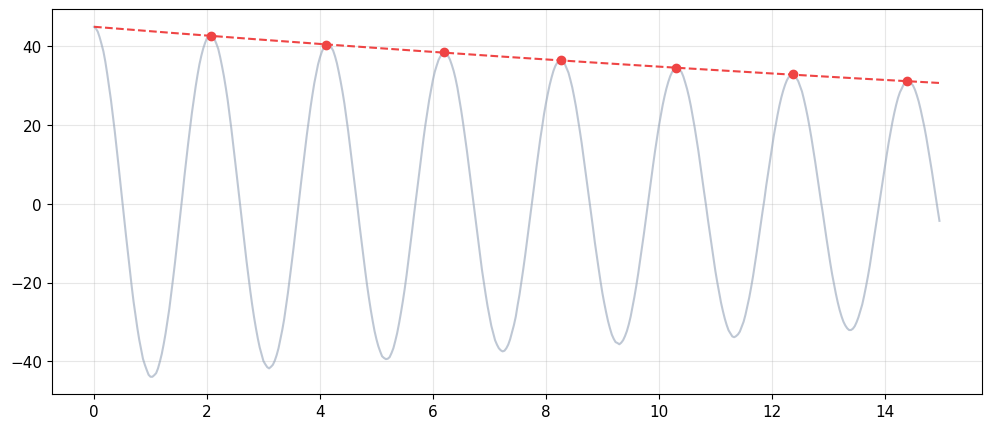

In [14]:
if len(peak_times) >= 3:
    peak_amplitudes = theta_measured[peak_indices]
    def exponential_decay(t, A0, gamma): return A0 * np.exp(-gamma * t)
    popt, _ = curve_fit(exponential_decay, peak_times, peak_amplitudes, p0=[peak_amplitudes[0], 0.01])
    
    print(f"\n📉 Ajuste de Amortiguamiento Exponencial:")
    print(f"   γ     = {popt[1]:.4f} s⁻¹")
    
    t_smooth = np.linspace(times[0], times[-1], 500)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(times, np.degrees(theta_measured), color="#94a3b8", alpha=0.6)
    ax.plot(peak_times, np.degrees(peak_amplitudes), "o", color="#ef4444")
    ax.plot(t_smooth, np.degrees(exponential_decay(t_smooth, *popt)), "--", color="#ef4444")
    plt.show()

---
## 7. Espectrograma (Análisis tiempo-frecuencia)

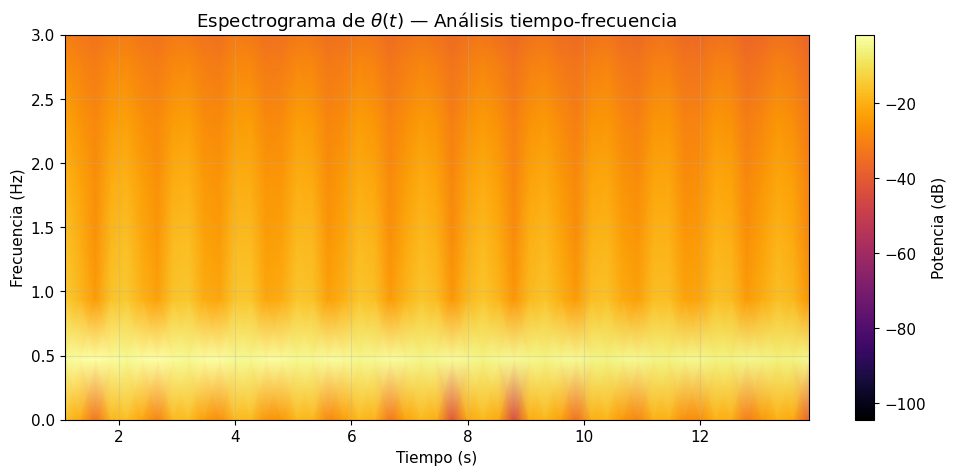

In [15]:
from scipy.signal import spectrogram
f_spec, t_spec, Sxx = spectrogram(theta_measured, fs=FPS, nperseg=64, noverlap=56)

fig, ax = plt.subplots(figsize=(12, 5))
pcm = ax.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap='inferno')
ax.set_ylim(0, 3)
ax.set_title("Espectrograma de $\\theta(t)$ — Análisis tiempo-frecuencia")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Frecuencia (Hz)")
plt.colorbar(pcm, ax=ax, label="Potencia (dB)")
plt.show()

---
## 8. Análisis de errores y limitaciones del método

In [16]:
print("\n" + "=" * 60)
print("   RESUMEN FINAL DE RESULTADOS")
print("=" * 60)
print(f"   Frames procesados    : {detections}/{frame_idx}")
print(f"   Duración analizada   : {times[-1]:.2f} s")
print("=" * 60)


   RESUMEN FINAL DE RESULTADOS
   Frames procesados    : 450/450
   Duración analizada   : 14.97 s
